In [74]:
import pandas as pd
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.preprocessing import LabelEncoder
#from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.graphics.mosaicplot import mosaic
import matplotlib.ticker as ticker


In [75]:
#### Activar segun quien trabaje 
#Marco
#Filepath = "C:/Users/user/OneDrive/Documentos/semestres uniandes/Clases 2025-1/Tesis IIND/Solo sector salud/Base analisis exploratorio.csv"
#Paula
Filepath = "C:\\Users\\paula\\OneDrive\\Documentos\\10 Semestre\\Tesis\\Repositorio\\Repositoriotesis\\Base analisis exploratorio.csv"
df = pd.read_csv(Filepath)
df

,nombre entidad,nit entidad,departamento,ciudad,orden,rama,entidad centralizada,estado contrato,codigo de categoria principal,tipo de contrato,...,fase,precio base,nombre de la unidad de contratación,departamento proveedor,ciudad proveedor,tiempo duracion (dias),duracion_proceso_dias,año_publicacion,porcentaje_pagado,Adicion
0,Otros,Otros,Meta,Villavicencio,Territorial,Ejecutivo,Centralizada,En ejecución,V1.85101600,Prestación de servicios,...,Presentación de oferta,8.273630e+06,Otros,Meta,Otros,38.0,39.0,2024,25-50%,0
1,SUBRED INTEGRADA DE SERVICIO DE SALUD CENTRO O...,900959051,Distrito Capital de Bogotá,Bogotá,Territorial,Ejecutivo,Descentralizada,En ejecución,V1.80111600,Prestación de servicios,...,Presentación de oferta,2.908492e+07,CONTRATACION OPS 2020,Distrito Capital de Bogotá,Bogotá,48.0,53.0,2020,0-25%,1
2,SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETARI...,890399011,Valle del Cauca,Cali,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111500,Prestación de servicios,...,Presentación de oferta,5.907958e+07,SECRETARIA DISTRITAL DE SALUD DE CALI,Valle del Cauca,Cali,50.0,57.0,2020,0-25%,0
3,SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E...,900971006,Distrito Capital de Bogotá,Bogotá,Territorial,Corporación Autónoma,Descentralizada,Activo,V1.85101600,Prestación de servicios,...,Presentación de oferta,3.440880e+07,Otros,Distrito Capital de Bogotá,No Definido,88.0,90.0,2018,0-25%,1
4,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,Otros,Prestación de servicios,...,Presentación de oferta,7.000000e+07,Grupo de contratación SECOP II,Magdalena,Santa Marta,57.0,60.0,2022,0-25%,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159178,Otros,Otros,Norte de Santander,Tibú,Territorial,Corporación Autónoma,Descentralizada,En ejecución,Otros,Decreto 092 de 2017,...,Presentación de oferta,1.427548e+08,Otros,Norte de Santander,Cúcuta,27.0,30.0,2023,75-100%,0
159179,ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARREN...,891780185,Magdalena,Santa Marta,Territorial,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,...,Presentación de oferta,9.000000e+06,Grupo de contratación SECOP II,Magdalena,Santa Marta,145.0,150.0,2022,0-25%,0
159180,Otros,Otros,Casanare,Yopal,Territorial,Ejecutivo,Descentralizada,En ejecución,V1.80111701,Prestación de servicios,...,Presentación de oferta,1.800000e+06,Otros,Casanare,Otros,30.0,30.0,2023,0-25%,0
159181,Otros,899999239,Nariño,No Definido,Nacional,Ejecutivo,Centralizada,En ejecución,V1.80111600,Prestación de servicios,...,Presentación de oferta,1.568828e+07,Otros,Nariño,Otros,175.0,173.0,2024,0-25%,0


In [76]:
df.columns

Index(['nombre entidad', 'nit entidad', 'departamento', 'ciudad', 'orden',
       'rama', 'entidad centralizada', 'estado contrato',
       'codigo de categoria principal', 'tipo de contrato',
       'modalidad de contratacion', 'justificacion modalidad de contratacion',
       'condiciones de entrega', 'es pyme', 'liquidación',
       'origen de los recursos', 'destino gasto', 'valor del contrato',
       'valor pendiente de pago', 'estado bpin', 'anno bpin',
       'el contrato puede ser prorrogado', 'fase', 'precio base',
       'nombre de la unidad de contratación', 'departamento proveedor',
       'ciudad proveedor', 'tiempo duracion (dias)', 'duracion_proceso_dias',
       'año_publicacion', 'porcentaje_pagado', 'Adicion'],
      dtype='object')

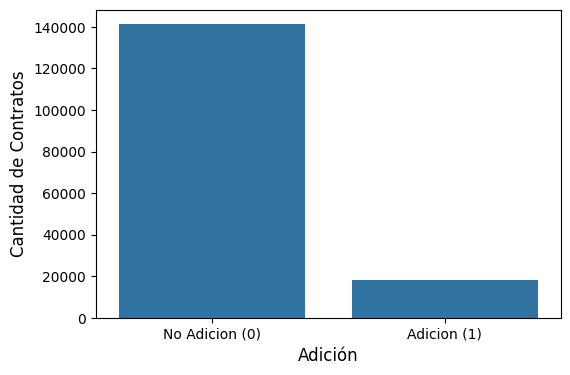

In [77]:
# Gráfico de barras para la distribución de "Adicion"
plt.figure(figsize=(6, 4))
sns.countplot(x="Adicion", data=df)
plt.xticks(ticks=[0, 1], labels=["No Adicion (0)", "Adicion (1)"])
plt.xlabel("Adición", fontsize=12)
plt.ylabel("Cantidad de Contratos", fontsize=12)
plt.show()


In [78]:
df["Adicion"].value_counts()

Adicion
0    141229
1     17954
Name: count, dtype: int64

In [79]:
141229/(141229+17954)

0.8872115741002494

Mapa de correlación variables continuas

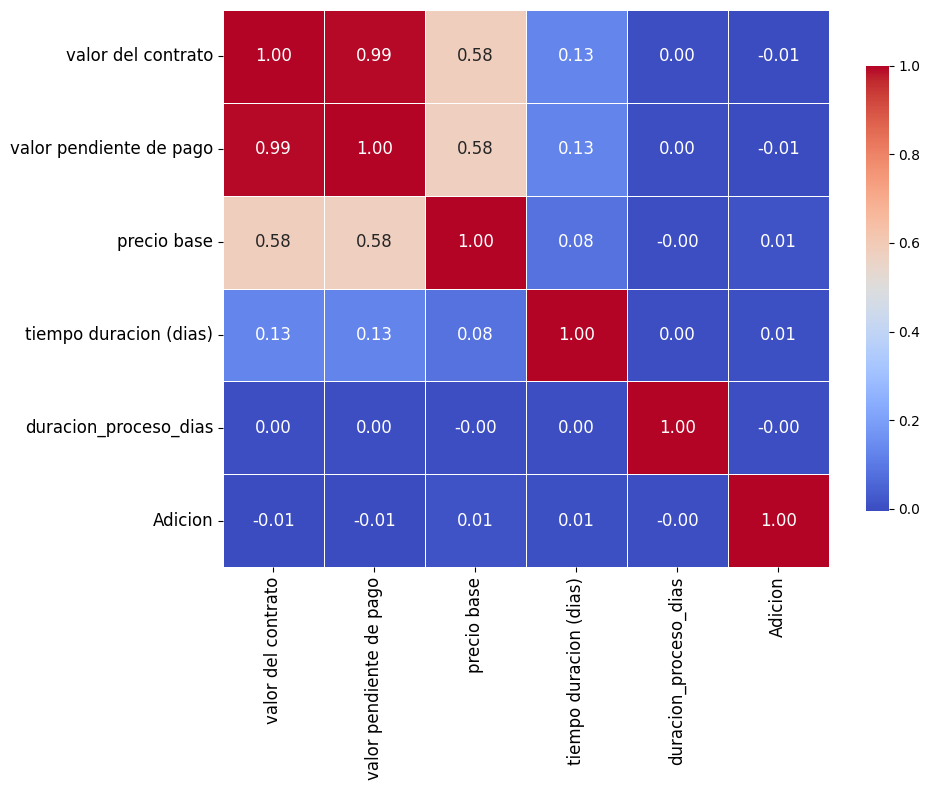

In [80]:
fig, ax = plt.subplots(figsize=(10, 8))  # Aumenté también el tamaño de la figura
correlation_matrix = df.select_dtypes(include=[np.number]).drop(columns=['año_publicacion']).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 12},  # Tamaño de los números dentro del mapa
    cbar_kws={"shrink": 0.8}
)

# Aumentar tamaño de los títulos de los ejes
ax.tick_params(axis='both', labelsize=12)  # Tamaño de etiquetas de ejes X e Y

plt.tight_layout()
plt.show()

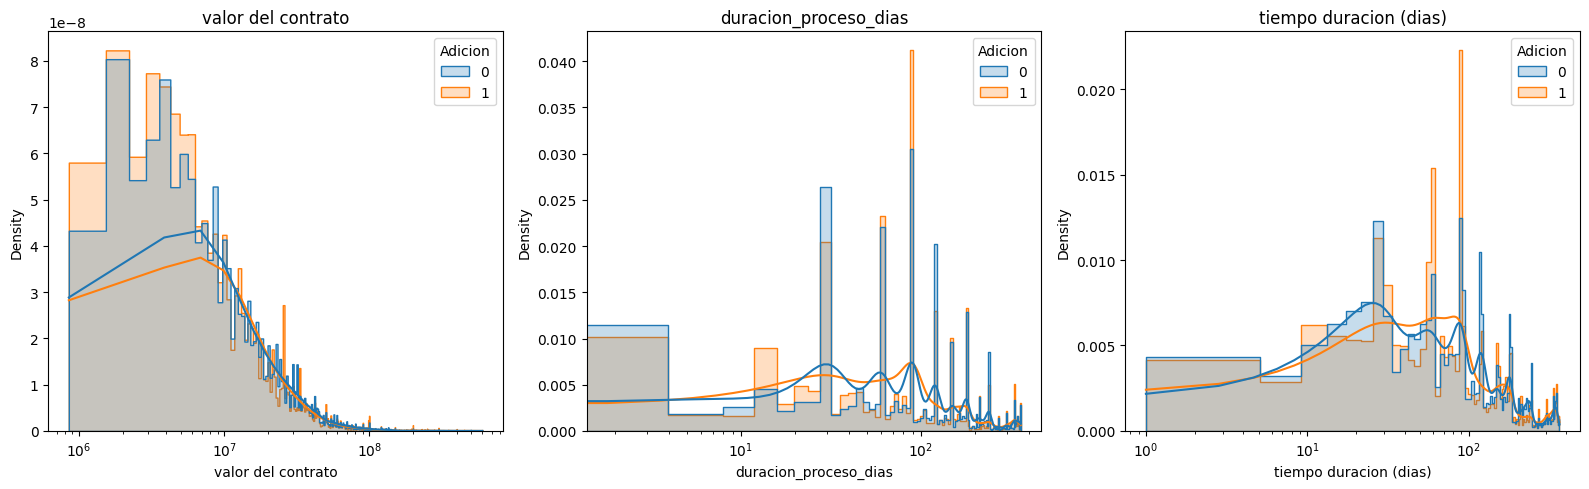

In [81]:
# Definir variables numéricas relevantes para analizar con "Adicion"
variables_numericas = ["valor del contrato", "duracion_proceso_dias", "tiempo duracion (dias)"]

# Filtrar valores extremos para mejorar la visualización (percentil 99)
df_filtered = df.copy()
for var in variables_numericas:
    upper_limit = np.percentile(df[var].dropna(), 99)
    df_filtered = df_filtered[df_filtered[var] <= upper_limit]

# Crear subgráficos con escala logarítmica en X para mejorar visibilidad
fig, axes = plt.subplots(1, len(variables_numericas), figsize=(16, 5))

for i, var in enumerate(variables_numericas):
    sns.histplot(df_filtered, x=var, hue="Adicion", element="step", kde=True, ax=axes[i], stat="density", common_norm=False)
    axes[i].set_title(var)
    axes[i].set_xscale("log")  # Aplicar escala logarítmica para mejor visibilidad

plt.tight_layout()
plt.show()



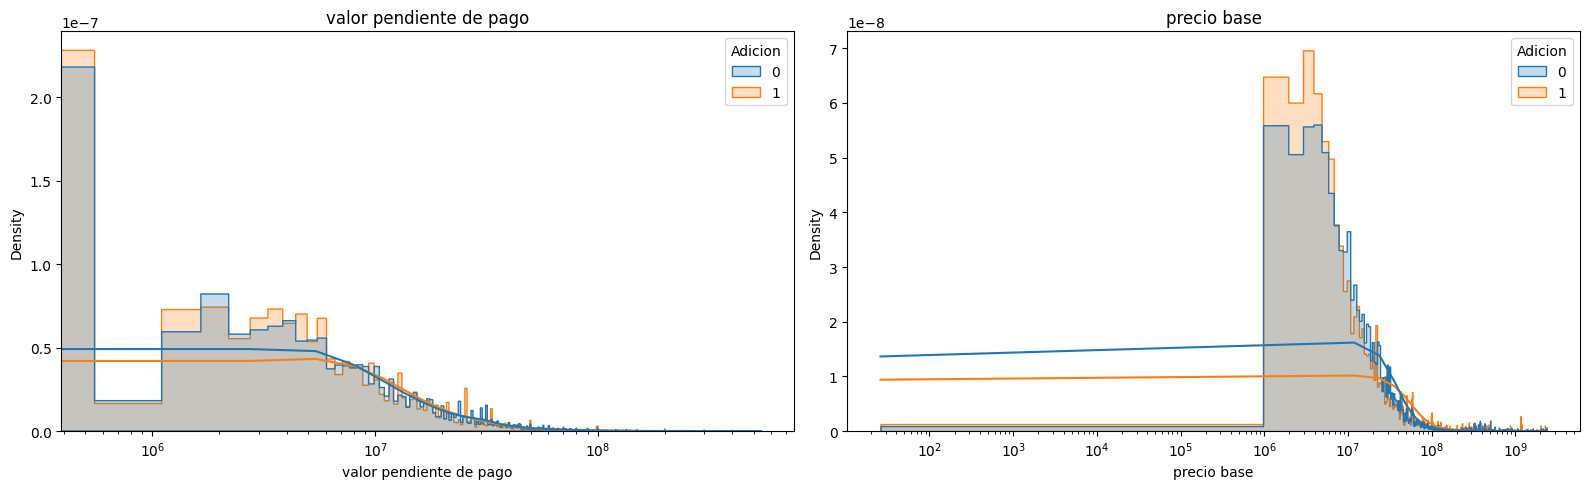

In [82]:
# Definir variables numéricas relevantes para analizar con "Adicion"
variables_numericas = ["valor pendiente de pago", "precio base"]

# Filtrar valores extremos para mejorar la visualización (percentil 99)
df_filtered = df.copy()
for var in variables_numericas:
    upper_limit = np.percentile(df[var].dropna(), 99)
    df_filtered = df_filtered[df_filtered[var] <= upper_limit]

# Crear subgráficos con escala logarítmica en X para mejorar visibilidad
fig, axes = plt.subplots(1, len(variables_numericas), figsize=(16, 5))

for i, var in enumerate(variables_numericas):
    sns.histplot(df_filtered, x=var, hue="Adicion", element="step", kde=True, ax=axes[i], stat="density", common_norm=False)
    axes[i].set_title(var)
    axes[i].set_xscale("log")  # Aplicar escala logarítmica para mejor visibilidad

plt.tight_layout()
plt.show()


C:\Users\paula\AppData\Local\Temp\ipykernel_9796\2750078798.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])  # Notación 10^#


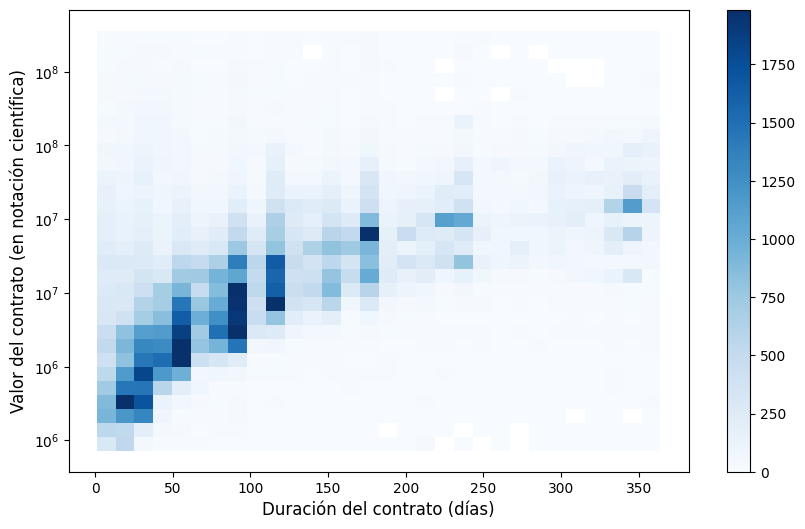

In [83]:
# Filtrar valores extremos para mejorar la visualización (percentil 99)
upper_limit_valor = np.percentile(df["valor del contrato"].dropna(), 99)
upper_limit_duracion = np.percentile(df["tiempo duracion (dias)"].dropna(), 99)
df_filtered = df[
    (df["valor del contrato"] <= upper_limit_valor) &
    (df["tiempo duracion (dias)"] <= upper_limit_duracion)
]

# --- Heatmap de conteo con escala logarítmica en el eje Y ---
plt.figure(figsize=(10, 6))
heatmap_data = df_filtered.copy()

# Aplicar log solo para visualización
heatmap_data["valor del contrato log"] = np.log10(heatmap_data["valor del contrato"])

# Crear heatmap
ax = sns.histplot(
    x="tiempo duracion (dias)",
    y="valor del contrato log",
    data=heatmap_data,
    bins=30,
    pmax=0.9,
    cmap="Blues",
    cbar=True
)

# Mejorar etiquetas del eje Y en notación científica 10^#
yticks = ax.get_yticks()
ax.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])  # Notación 10^#

plt.xlabel("Duración del contrato (días)", fontsize=12)
plt.ylabel("Valor del contrato (en notación científica)", fontsize=12)
plt.show()


In [84]:
df.describe()

,valor del contrato,valor pendiente de pago,precio base,tiempo duracion (dias),duracion_proceso_dias,año_publicacion,Adicion
count,1.591830e+05,1.591830e+05,1.591830e+05,159183.000000,1.591810e+05,159183.000000,159183.000000
mean,4.390507e+07,3.890762e+07,1.065298e+08,114.701036,2.194688e+02,2022.840913,0.112788
std,4.876089e+08,4.826571e+08,6.834417e+08,101.619758,3.093507e+04,1.783101,0.316335
min,8.500000e+05,0.000000e+00,2.600000e+01,1.000000,0.000000e+00,2016.000000,0.000000
25%,4.894888e+06,2.988300e+06,5.557365e+06,43.000000,4.500000e+01,2022.000000,0.000000
50%,1.050000e+07,7.740000e+06,1.340000e+07,88.000000,9.000000e+01,2023.000000,0.000000
75%,2.389090e+07,1.814400e+07,3.300000e+07,160.000000,1.610000e+02,2024.000000,0.000000
max,8.659934e+10,8.659934e+10,9.375000e+10,3910.000000,1.206000e+07,2025.000000,1.000000


C:\Users\paula\AppData\Local\Temp\ipykernel_9796\163520873.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
C:\Users\paula\AppData\Local\Temp\ipykernel_9796\163520873.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])


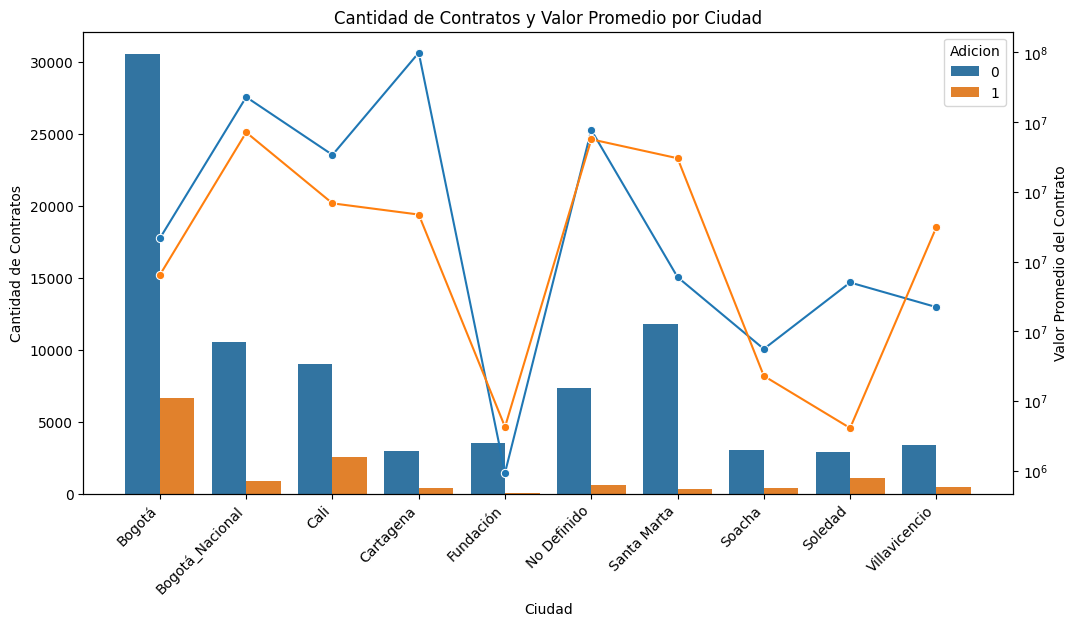

In [85]:
# Filtrar las 10 ciudades con más contratos
top_cities = df["ciudad"].value_counts().head(10).index
df_filtered = df[df["ciudad"].isin(top_cities)]

# Agrupar por ciudad y adición para obtener cantidad y valor promedio
df_grouped = df_filtered.groupby(["ciudad", "Adicion"]).agg(
    cantidad_contratos=("valor del contrato", "count"),
    valor_promedio=("valor del contrato", "mean")
).reset_index()

# --- Opción: Barras apiladas + Línea de tendencia con notación 10^x ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico de barras: Cantidad de contratos por ciudad y adición
sns.barplot(x="ciudad", y="cantidad_contratos", hue="Adicion", data=df_grouped, ax=ax1)
ax1.set_ylabel("Cantidad de Contratos")
ax1.set_xlabel("Ciudad")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.set_title("Cantidad de Contratos y Valor Promedio por Ciudad")

# Segundo eje para la línea de tendencia del valor promedio del contrato
ax2 = ax1.twinx()
sns.lineplot(x="ciudad", y=np.log10(df_grouped["valor_promedio"]), hue="Adicion", data=df_grouped, marker="o", ax=ax2, legend=False)
ax2.set_ylabel("Valor Promedio del Contrato")

# Ajustar etiquetas en notación científica 10^x
yticks = ax2.get_yticks()
ax2.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])

plt.show()


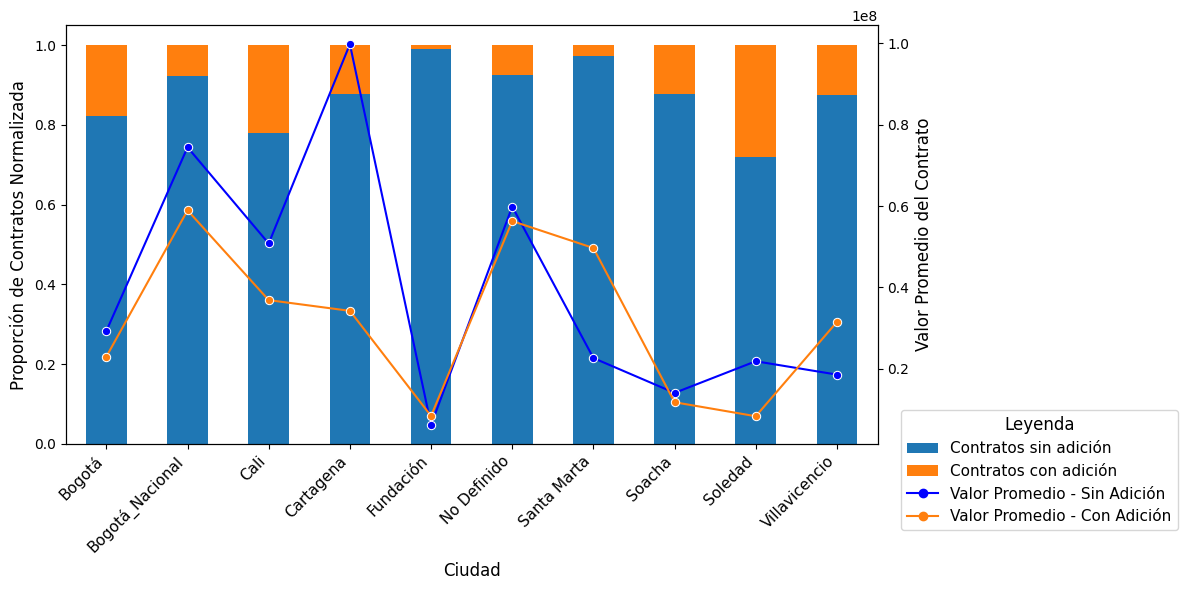

In [86]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

# Paletas
bar_palette = {0: "#1f77b4", 1: "#ff7f0e"}
line_palette = {0: "blue", 1: "#ff7f0e"}

# Figura y ejes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras apiladas (normalizadas)
df_pivot = df_grouped.pivot(index="ciudad", columns="Adicion", values="cantidad_contratos").fillna(0)
df_pivot = df_pivot.div(df_pivot.sum(axis=1), axis=0)
df_pivot.plot(kind="bar", stacked=True, color=[bar_palette[0], bar_palette[1]], ax=ax1)

ax1.set_ylabel("Proporción de Contratos Normalizada", fontsize=12)
ax1.set_xlabel("Ciudad", fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right", fontsize=11)

# Segundo eje para líneas
ax2 = ax1.twinx()

for adicion in df_grouped["Adicion"].unique():
    df_line = df_grouped[df_grouped["Adicion"] == adicion]
    sns.lineplot(x=df_line["ciudad"], y=df_line["valor_promedio"], marker="o",
                 ax=ax2, color=line_palette[adicion])

ax2.set_ylabel("Valor Promedio del Contrato", fontsize=12)

# -------------------
# Leyenda personalizada
# -------------------

legend_elements = [
    Patch(facecolor=bar_palette[0], label="Contratos sin adición"),
    Patch(facecolor=bar_palette[1], label="Contratos con adición"),
    Line2D([0], [0], color=line_palette[0], marker='o', label="Valor Promedio - Sin Adición"),
    Line2D([0], [0], color=line_palette[1], marker='o', label="Valor Promedio - Con Adición")
]

ax1.legend(handles=legend_elements, title="Leyenda", title_fontsize=12,
           loc='upper left', bbox_to_anchor=(1.02, 0.1), fontsize=11)

plt.tight_layout()
plt.show()




In [87]:
# Crear el diccionario con NIT como clave y nombre de la entidad como valor
diccionario_nit = df.set_index('nit entidad')['nombre entidad'].to_dict()

# Mostrar el diccionario
print(diccionario_nit)

{'Otros': 'Otros', '900959051': 'SUBRED INTEGRADA DE SERVICIO DE SALUD CENTRO ORIENTE E.S.E 1', '890399011': 'SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETARIA DISTRITAL DE SALUD DE CALI', '900971006': 'SUBRED INTEGRADA DE SERVICIOS DE SALUD NORTE E.S.E. (OFICIAL)', '891780185': 'ESE HOSPITAL UNIVERSITARIO JULIO MENDEZ BARRENECHE', '900959048': 'SUBRED INTEGRADA DE SERVICIOS DE SALUD SUR OCCIDENTE ESE.', '899999239': 'Otros', '900958564': 'SUBRED INTEGRADA DE SERVICIOS DE SALUD SUR E.S.E.', '8002469532': 'FONDO FINANCIERO DISTRITAL DE SALUD.', '900474727': 'MINISTERIO DE SALUD Y PROTECCIÓN SOCIAL', '899999333': 'INSTITUTO DISTRITAL PARA LA PROTECCIÓN DE LA NIÑEZ Y LA JUVENTUD - IDIPRON*', '899999114': 'DEPARTAMENTO DE CUNDINAMARCA- SECRETARIA DE SALUD'}


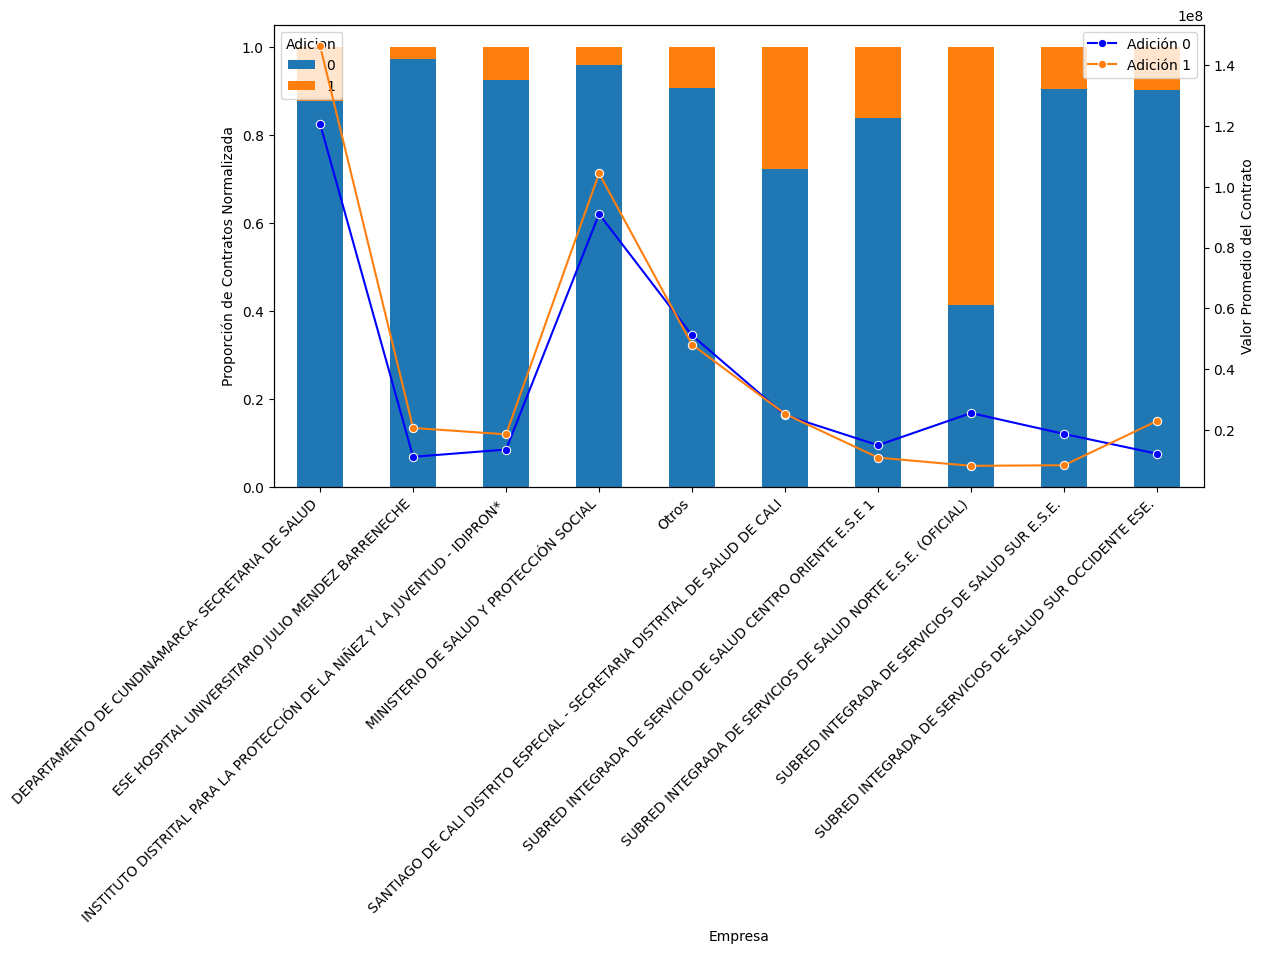

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir la paleta de colores: barras mantienen azul/naranja, líneas usan colores más brillantes
bar_palette = {0: "#1f77b4", 1: "#ff7f0e"}  # Azul y Naranja (Barras)
line_palette = {0: "blue", 1: "#ff7f0e"}  # Azul y Naranja (Líneas)

# Filtrar las 10 empresas con más contratos
top_companies = df["nombre entidad"].value_counts().head(10).index
df_filtered = df[df["nombre entidad"].isin(top_companies)]

# Agrupar por empresa y adición para obtener cantidad y valor promedio
df_grouped = df_filtered.groupby(["nombre entidad", "Adicion"]).agg(
    cantidad_contratos=("valor del contrato", "count"),
    valor_promedio=("valor del contrato", "mean")
).reset_index()

# Crear figura y ejes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Pivotar para barras apiladas (normalizadas)
df_pivot = df_grouped.pivot(index="nombre entidad", columns="Adicion", values="cantidad_contratos").fillna(0)
df_pivot = df_pivot.div(df_pivot.sum(axis=1), axis=0)  # Normalizar para proporción de contratos

# Graficar barras apiladas con los colores corregidos (normalizadas)
df_pivot.plot(kind="bar", stacked=True, color=[bar_palette[0], bar_palette[1]], ax=ax1)
ax1.set_ylabel("Proporción de Contratos Normalizada")
ax1.set_xlabel("Empresa")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

# Segundo eje para la línea de tendencia del valor promedio del contrato (NO NORMALIZADO)
ax2 = ax1.twinx()

# Graficar líneas con colores más brillantes y valores reales (NO normalizados)
for adicion in df_grouped["Adicion"].unique():
    df_line = df_grouped[df_grouped["Adicion"] == adicion]
    sns.lineplot(x=df_line["nombre entidad"], y=df_line["valor_promedio"], marker="o", 
                 ax=ax2, label=f"Adición {adicion}", color=line_palette[adicion])

ax2.set_ylabel("Valor Promedio del Contrato")

plt.show()


C:\Users\paula\AppData\Local\Temp\ipykernel_9796\457826166.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["nombre_empresa"] = df_filtered["nit entidad"].map(diccionario_nit)


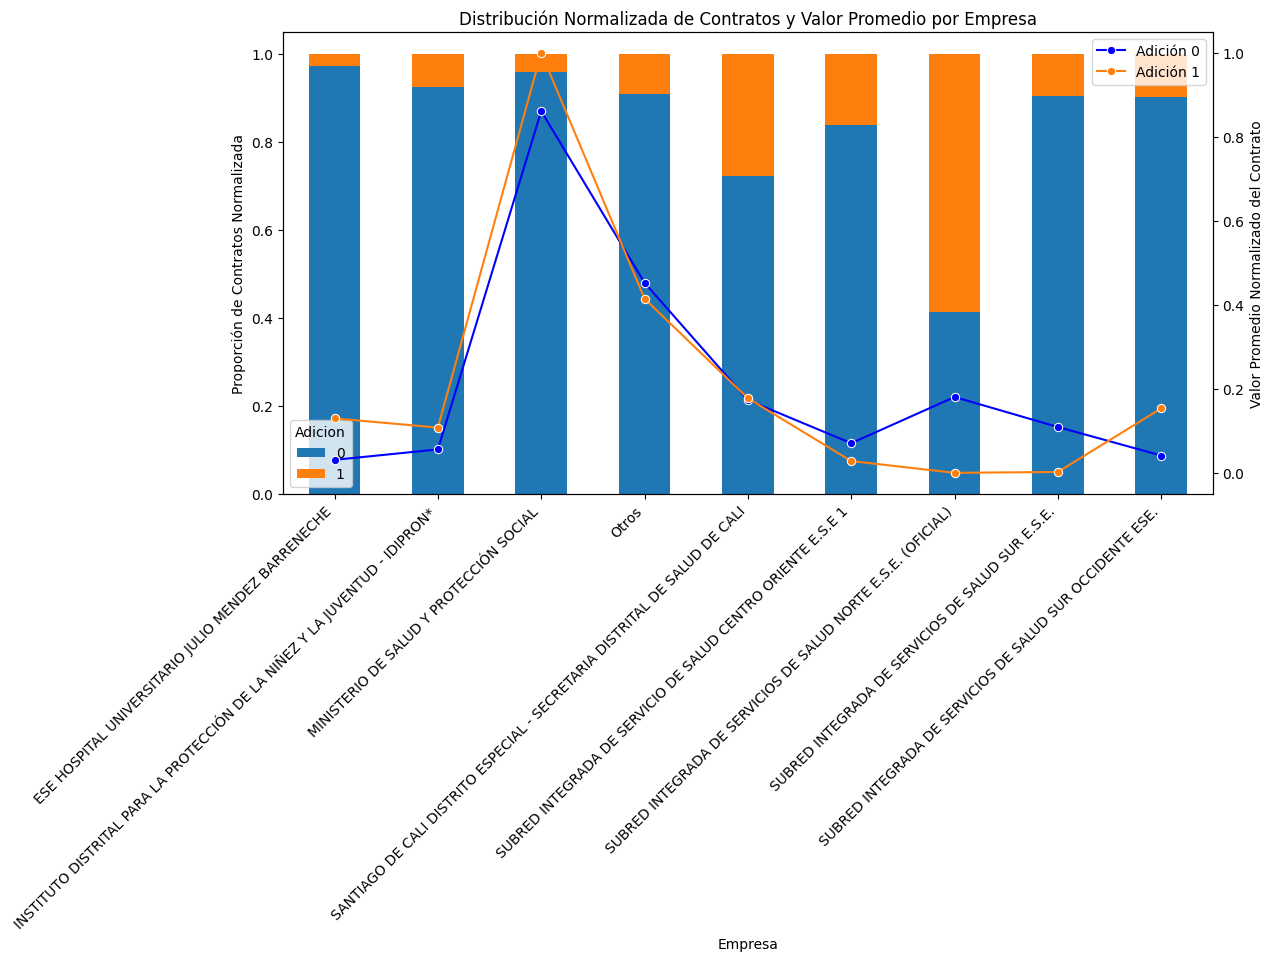

In [89]:
# Definir la paleta de colores: barras mantienen azul/naranja, líneas usan colores más brillantes
bar_palette = {0: "#1f77b4", 1: "#ff7f0e"}  # Azul y Naranja (Barras)
line_palette = {0: "blue", 1: "#ff7f0e"}  # Cian y Rojo (Líneas)

# Filtrar las 10 empresas con más contratos
top_companies = df["nit entidad"].value_counts().head(10).index
df_filtered = df[df["nit entidad"].isin(top_companies)]

# Reemplazar NIT por nombres de empresas usando el diccionario
df_filtered["nombre_empresa"] = df_filtered["nit entidad"].map(diccionario_nit)

# Agrupar por empresa y adición para obtener cantidad y valor promedio
df_grouped = df_filtered.groupby(["nombre_empresa", "Adicion"]).agg(
    cantidad_contratos=("valor del contrato", "count"),
    valor_promedio=("valor del contrato", "mean")
).reset_index()

# Normalizar el valor promedio del contrato usando min-max
min_valor_promedio = df_grouped["valor_promedio"].min()
max_valor_promedio = df_grouped["valor_promedio"].max()
df_grouped["valor_promedio_normalizado"] = (df_grouped["valor_promedio"] - min_valor_promedio) / (max_valor_promedio - min_valor_promedio)

# Crear figura y ejes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Pivotar para barras apiladas
df_pivot = df_grouped.pivot(index="nombre_empresa", columns="Adicion", values="cantidad_contratos").fillna(0)
df_pivot = df_pivot.div(df_pivot.sum(axis=1), axis=0)  # Normalizar

# Graficar barras apiladas con los colores corregidos
df_pivot.plot(kind="bar", stacked=True, color=[bar_palette[0], bar_palette[1]], ax=ax1)
ax1.set_ylabel("Proporción de Contratos Normalizada")
ax1.set_xlabel("Empresa")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.set_title("Distribución Normalizada de Contratos y Valor Promedio por Empresa")

# Segundo eje para la línea de tendencia del valor promedio del contrato
ax2 = ax1.twinx()

# Graficar líneas con colores más brillantes
for adicion in df_grouped["Adicion"].unique():
    df_line = df_grouped[df_grouped["Adicion"] == adicion]
    sns.lineplot(x=df_line["nombre_empresa"], y=df_line["valor_promedio_normalizado"], marker="o", 
                 ax=ax2, label=f"Adición {adicion}", color=line_palette[adicion])

ax2.set_ylabel("Valor Promedio Normalizado del Contrato")

plt.show()

C:\Users\paula\AppData\Local\Temp\ipykernel_9796\2296921309.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
C:\Users\paula\AppData\Local\Temp\ipykernel_9796\2296921309.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])


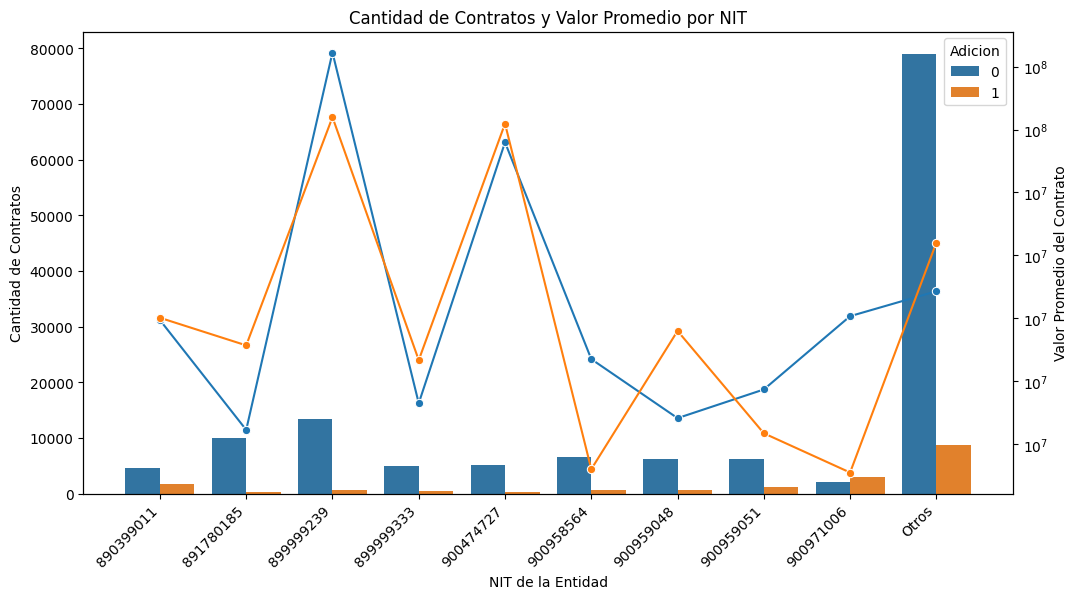

In [90]:

# Filtrar los 10 NIT con más contratos
top_nits = df["nit entidad"].value_counts().head(10).index
df_filtered = df[df["nit entidad"].isin(top_nits)]

# Agrupar por NIT y Adición para obtener cantidad y valor promedio
df_grouped = df_filtered.groupby(["nit entidad", "Adicion"]).agg(
    cantidad_contratos=("valor del contrato", "count"),
    valor_promedio=("valor del contrato", "mean")
).reset_index()

# --- Barras apiladas + Línea de tendencia con notación 10^x ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico de barras: Cantidad de contratos por NIT y Adición
sns.barplot(x="nit entidad", y="cantidad_contratos", hue="Adicion", data=df_grouped, ax=ax1)
ax1.set_ylabel("Cantidad de Contratos")
ax1.set_xlabel("NIT de la Entidad")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.set_title("Cantidad de Contratos y Valor Promedio por NIT")

# Segundo eje para la línea de tendencia del valor promedio del contrato
ax2 = ax1.twinx()
sns.lineplot(x="nit entidad", y=np.log10(df_grouped["valor_promedio"]), hue="Adicion", data=df_grouped, marker="o", ax=ax2, legend=False)
ax2.set_ylabel("Valor Promedio del Contrato")

# Ajustar etiquetas en notación científica 10^x
yticks = ax2.get_yticks()
ax2.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])

plt.show()


C:\Users\paula\AppData\Local\Temp\ipykernel_9796\3399802680.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
C:\Users\paula\AppData\Local\Temp\ipykernel_9796\3399802680.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])


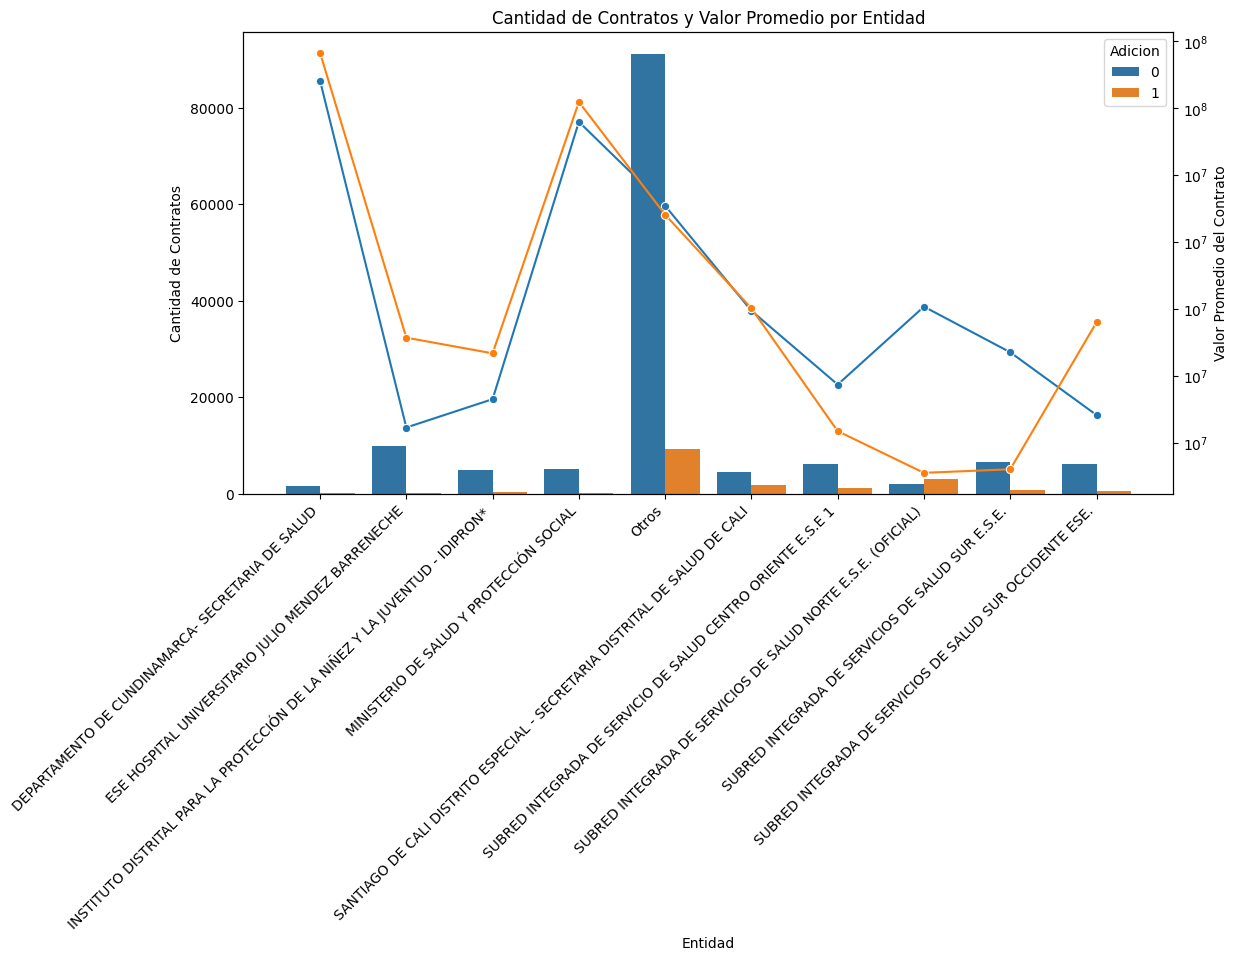

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filtrar las 10 entidades con más contratos
top_entidades = df["nombre entidad"].value_counts().head(10).index
df_filtered = df[df["nombre entidad"].isin(top_entidades)]

# Agrupar por entidad y adición para obtener cantidad y valor promedio
df_grouped = df_filtered.groupby(["nombre entidad", "Adicion"]).agg(
    cantidad_contratos=("valor del contrato", "count"),
    valor_promedio=("valor del contrato", "mean")
).reset_index()

# --- Barras apiladas + Línea de tendencia con notación 10^x ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Gráfico de barras: Cantidad de contratos por entidad y Adición
sns.barplot(x="nombre entidad", y="cantidad_contratos", hue="Adicion", data=df_grouped, ax=ax1)
ax1.set_ylabel("Cantidad de Contratos")
ax1.set_xlabel("Entidad")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
ax1.set_title("Cantidad de Contratos y Valor Promedio por Entidad")

# Segundo eje para la línea de tendencia del valor promedio del contrato
ax2 = ax1.twinx()
sns.lineplot(x="nombre entidad", y=np.log10(df_grouped["valor_promedio"]), hue="Adicion", data=df_grouped, marker="o", ax=ax2, legend=False)
ax2.set_ylabel("Valor Promedio del Contrato")

# Ajustar etiquetas en notación científica 10^x
yticks = ax2.get_yticks()
ax2.set_yticklabels([f"$10^{{{int(tick)}}}$" for tick in yticks])

plt.show()


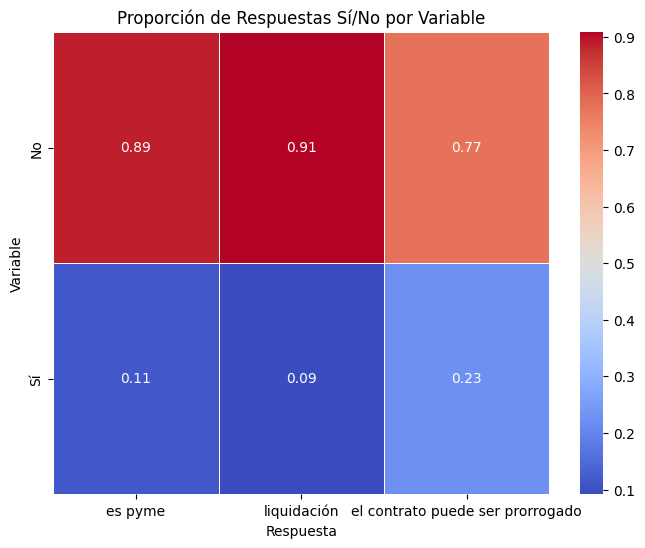

<Figure size 800x600 with 0 Axes>

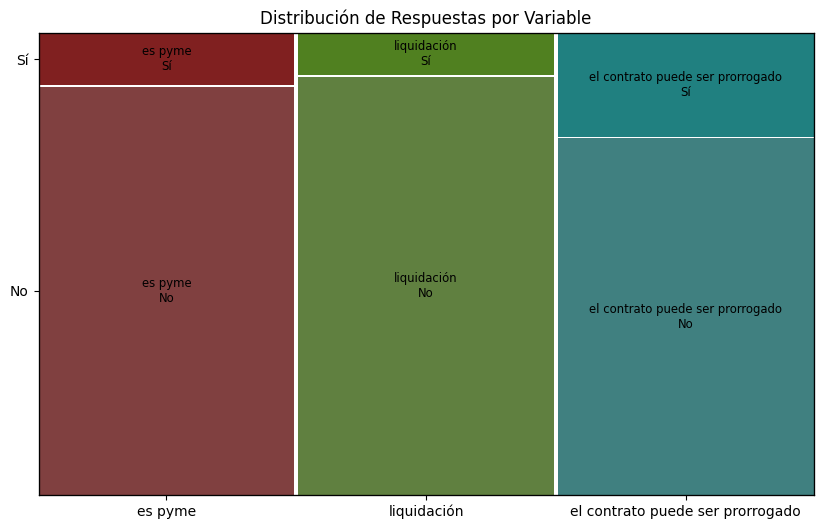

In [92]:
# Seleccionar las variables binarias
binary_vars = ["es pyme", "liquidación", "el contrato puede ser prorrogado"]

# Convertir respuestas a categóricas (asegurando que sean solo "Sí" o "No")
for col in binary_vars:
    df[col] = df[col].astype(str).str.strip().str.lower()  # Normalizar
    df[col] = df[col].map({"sí": "Sí", "si": "Sí", "no": "No"})  # Unificar respuestas

# --- Opción 1: Heatmap de proporciones ---
plt.figure(figsize=(8, 6))
heatmap_data = df[binary_vars].apply(lambda x: x.value_counts(normalize=True))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Proporción de Respuestas Sí/No por Variable")
plt.xlabel("Respuesta")
plt.ylabel("Variable")
plt.show()

# --- Opción 2: Matriz de Mosaico ---
plt.figure(figsize=(8, 6))
mosaic_data = pd.DataFrame(df[binary_vars].apply(pd.Series.value_counts).T)
mosaic_data = mosaic_data / mosaic_data.sum(axis=1).values[:, None]  # Convertir a proporciones
mosaic_dict = {(var, res): mosaic_data.loc[var, res] for var in mosaic_data.index for res in mosaic_data.columns}

fig, ax = plt.subplots(figsize=(10, 6))
mosaic(mosaic_dict, title="Distribución de Respuestas por Variable", ax=ax)
plt.show()



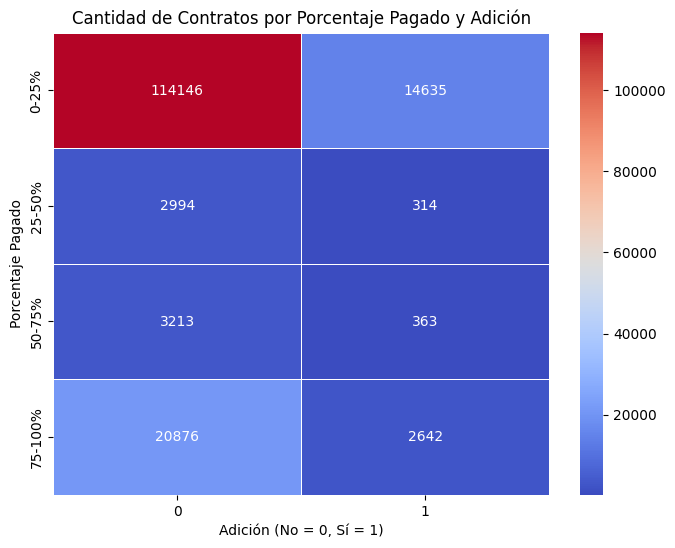

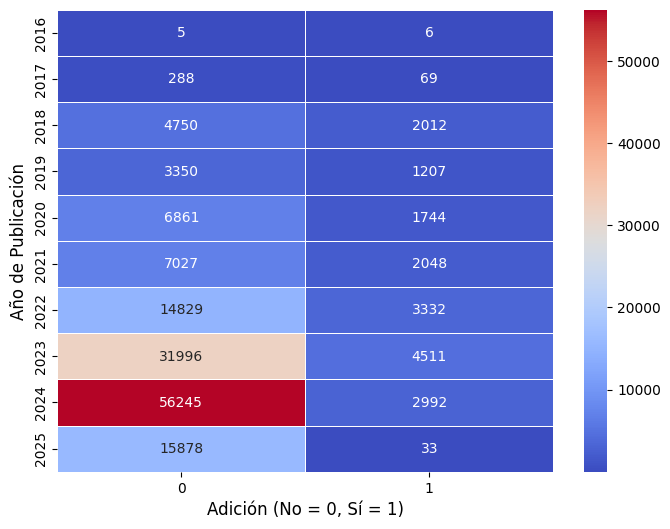

In [93]:
# --- Opción 1: Heatmap con porcentaje pagado en el eje Y y cantidad de contratos en las celdas ---
plt.figure(figsize=(8, 6))
heatmap_data = df.pivot_table(values="año_publicacion", 
                              index="porcentaje_pagado", 
                              columns="Adicion", 
                              aggfunc="count", 
                              fill_value=0)

ax = sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, fmt="d")
ax.set_xlabel("Adición (No = 0, Sí = 1)")
ax.set_ylabel("Porcentaje Pagado")
ax.set_title("Cantidad de Contratos por Porcentaje Pagado y Adición")
plt.show()

# --- Opción 2: Heatmap con año en el eje Y y cantidad de contratos en las celdas ---
plt.figure(figsize=(8, 6))
heatmap_data = df.pivot_table(values="porcentaje_pagado", 
                              index="año_publicacion", 
                              columns="Adicion", 
                              aggfunc="count", 
                              fill_value=0)

ax = sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, fmt="d")
ax.set_xlabel("Adición (No = 0, Sí = 1)", fontsize=12)
ax.set_ylabel("Año de Publicación", fontsize=12)
plt.show()


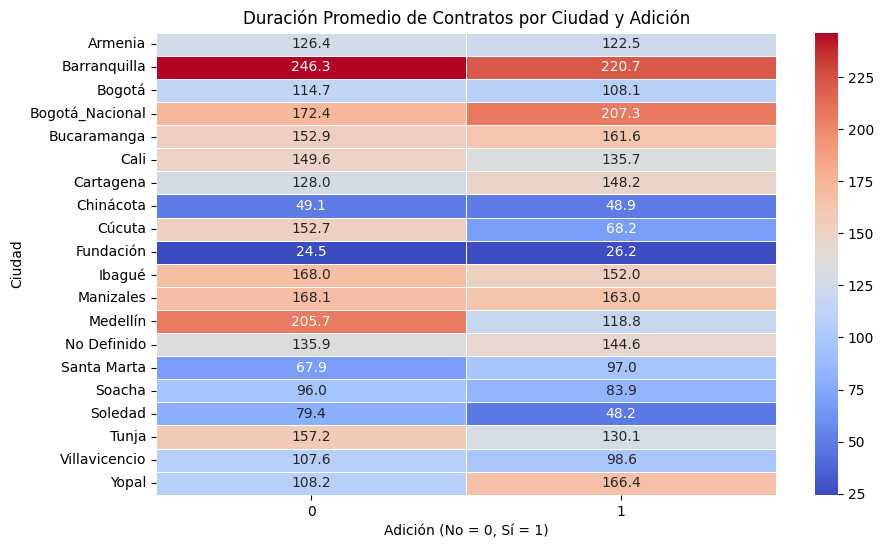

In [94]:
# Filtrar las 10 ciudades con más contratos
top_cities = df["ciudad"].value_counts().head(20).index
df_filtered = df[df["ciudad"].isin(top_cities)]

# Crear heatmap con duración promedio en días por ciudad y adición
heatmap_data = df_filtered.pivot_table(values="tiempo duracion (dias)", 
                                       index="ciudad", 
                                       columns="Adicion", 
                                       aggfunc="mean", 
                                       fill_value=0)

# Graficar el heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".1f")

# Ajustes de etiquetas
ax.set_xlabel("Adición (No = 0, Sí = 1)")
ax.set_ylabel("Ciudad")
ax.set_title("Duración Promedio de Contratos por Ciudad y Adición")

plt.show()


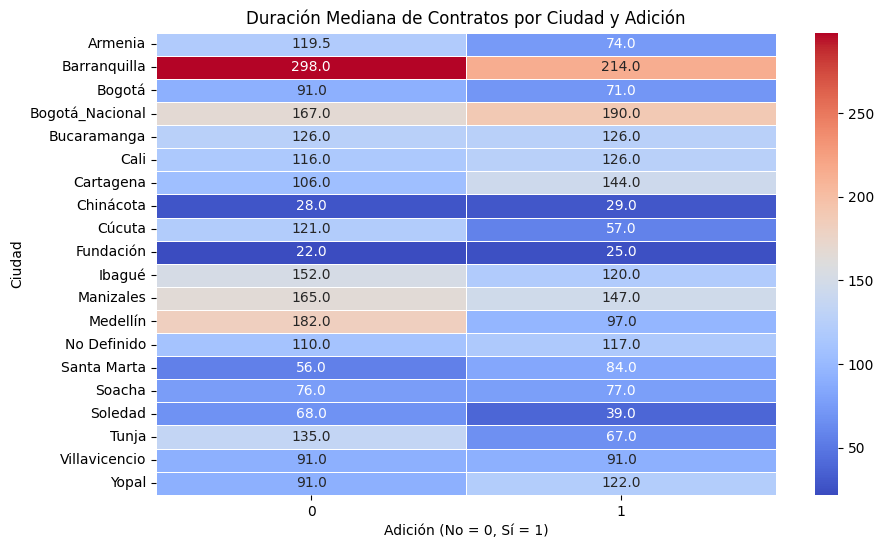

In [95]:
# Filtrar las 10 ciudades con más contratos
top_cities = df["ciudad"].value_counts().head(20).index
df_filtered = df[df["ciudad"].isin(top_cities)]

# Crear heatmap con duración mediana en días por ciudad y adición
heatmap_data = df_filtered.pivot_table(values="tiempo duracion (dias)", 
                                       index="ciudad", 
                                       columns="Adicion", 
                                       aggfunc="median", 
                                       fill_value=0)

# Graficar el heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".1f")

# Ajustes de etiquetas
ax.set_xlabel("Adición (No = 0, Sí = 1)")
ax.set_ylabel("Ciudad")
ax.set_title("Duración Mediana de Contratos por Ciudad y Adición")

plt.show()

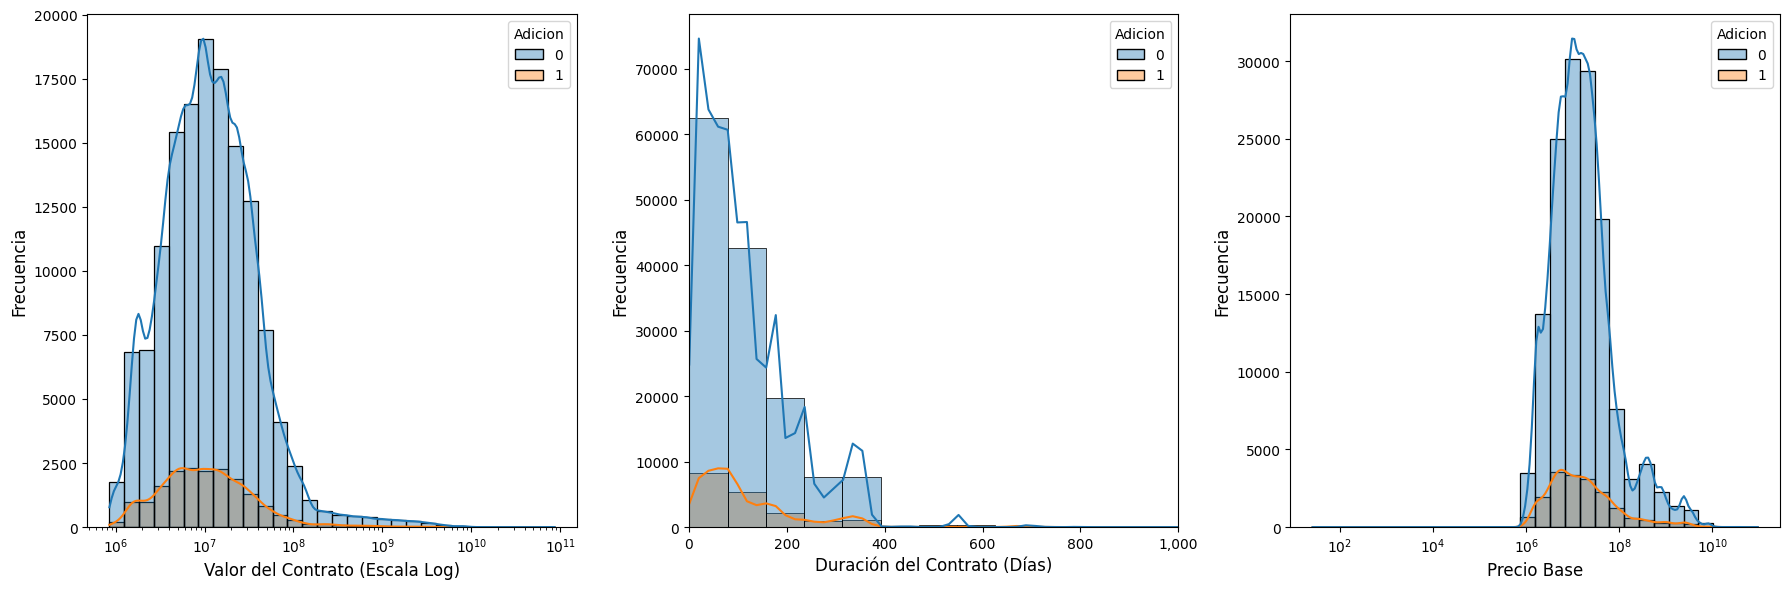

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Filtrar datos sin modificar el DataFrame original
df_filtered = df.copy()

# Convertir columnas a numéricas para evitar problemas con valores de texto
columns_to_check = ["valor del contrato", "tiempo duracion (dias)", "valor pendiente de pago", "precio base", "Adicion"]
df_filtered[columns_to_check] = df_filtered[columns_to_check].apply(pd.to_numeric, errors="coerce")

# Reemplazar valores Inf por NaN y luego eliminar NaNs
df_filtered.replace([np.inf, -np.inf], np.nan, inplace=True)
df_filtered.dropna(subset=columns_to_check, inplace=True)


# Crear una figura con una fila y tres columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 1. Valor del contrato vs. Adición ---
sns.histplot(df_filtered, x="valor del contrato", hue="Adicion", kde=True, bins=30, alpha=0.4, log_scale=(True, False), ax=axes[0])
axes[0].set_xlabel("Valor del Contrato (Escala Log)", fontsize=12)
axes[0].set_ylabel("Frecuencia", fontsize=12)

# --- 2. Duración del contrato vs. Adición ---
ax = sns.histplot(df_filtered, x="tiempo duracion (dias)", hue="Adicion", kde=True, bins=50, alpha=0.4, ax=axes[1])
ax.set_xlim(0, 1000)  # Ajustar según la distribución
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
axes[1].set_xlabel("Duración del Contrato (Días)", fontsize=12)
axes[1].set_ylabel("Frecuencia", fontsize=12)

# --- 3. Precio base vs. Adición ---
sns.histplot(df_filtered, x="precio base", hue="Adicion", kde=True, bins=30, alpha=0.4, log_scale=(True, False), ax=axes[2])
axes[2].set_xlabel("Precio Base", fontsize=12)
axes[2].set_ylabel("Frecuencia", fontsize=12)

# Ajustar el layout para que no se solapen los gráficos
plt.tight_layout()
plt.show()

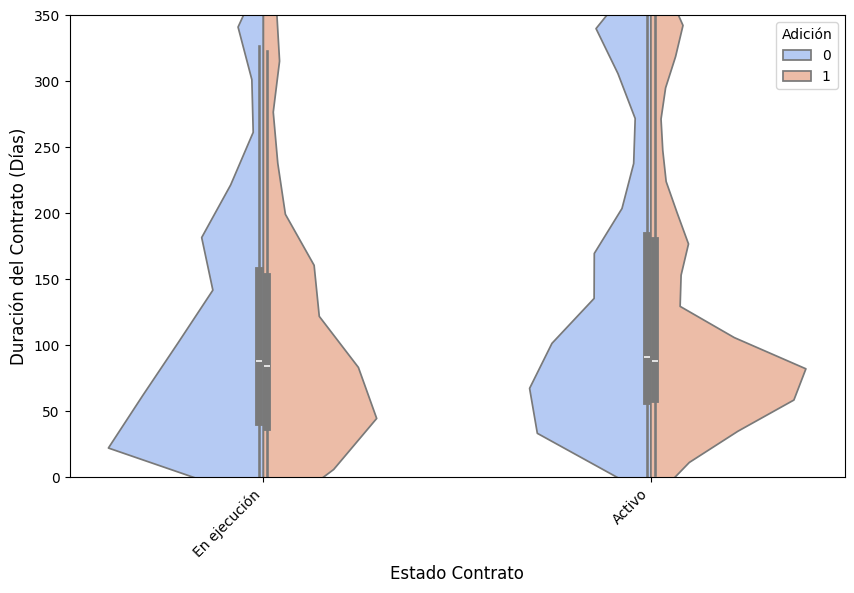

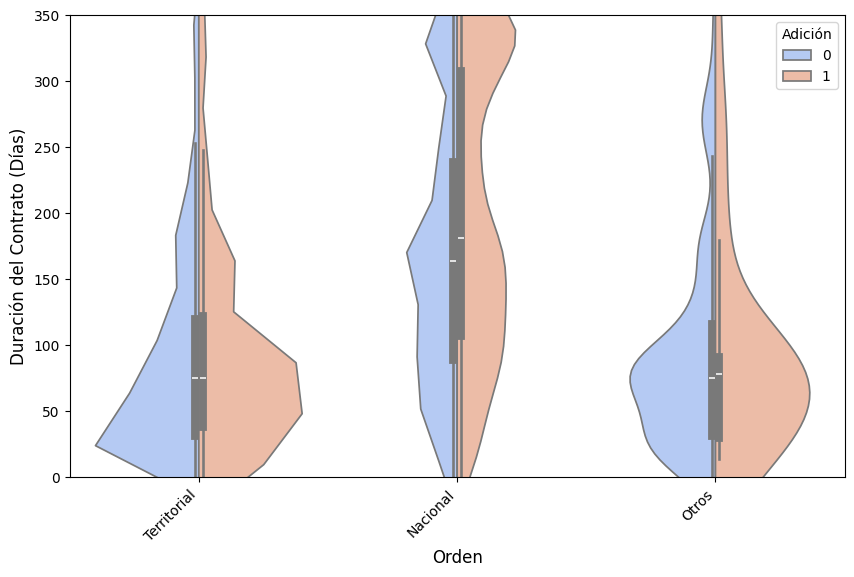

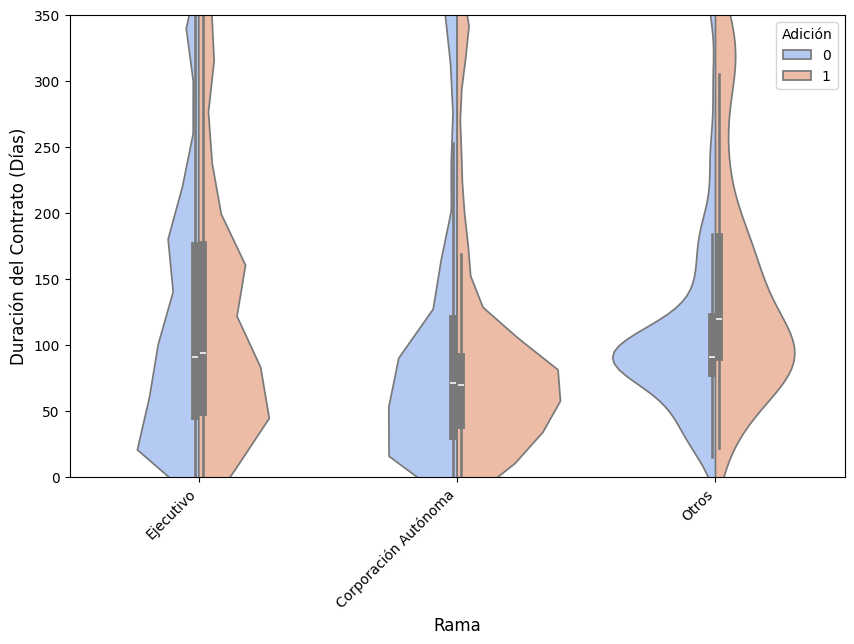

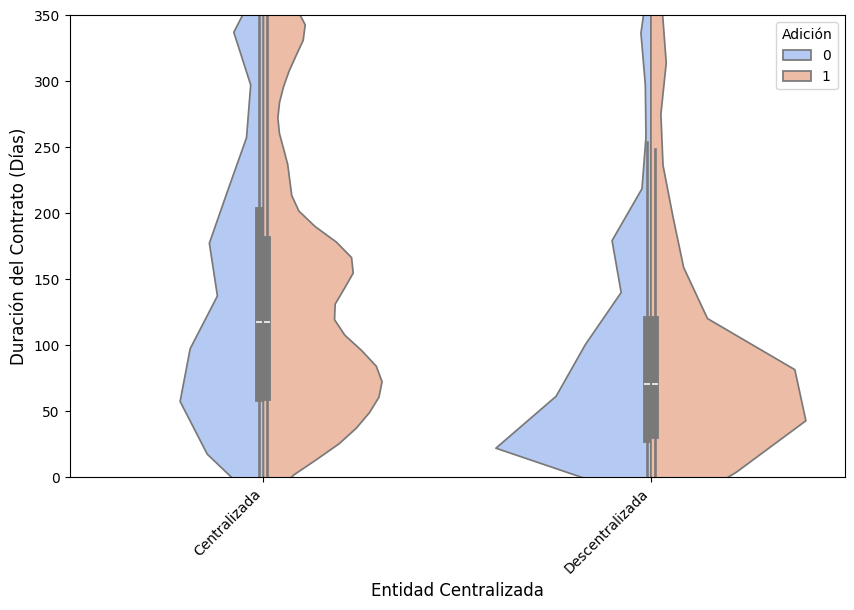

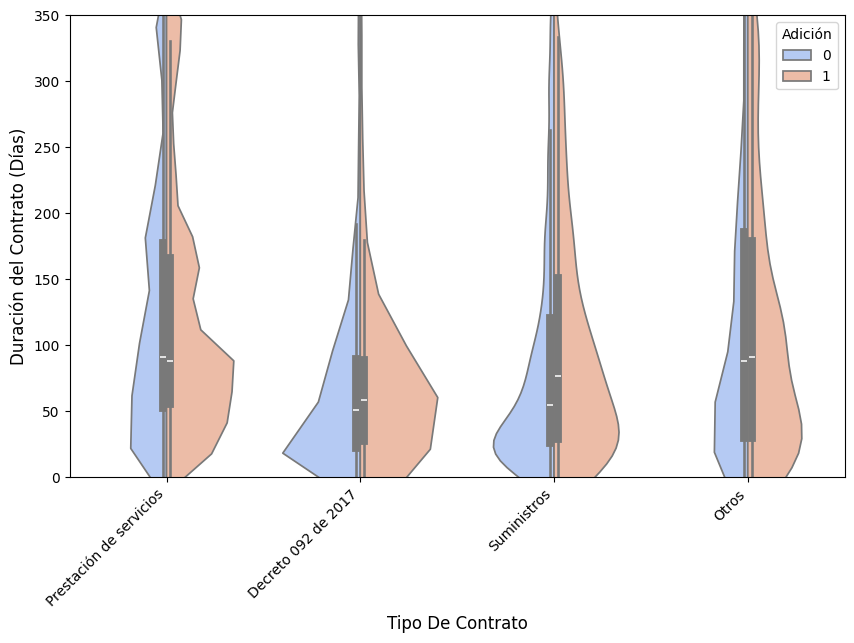

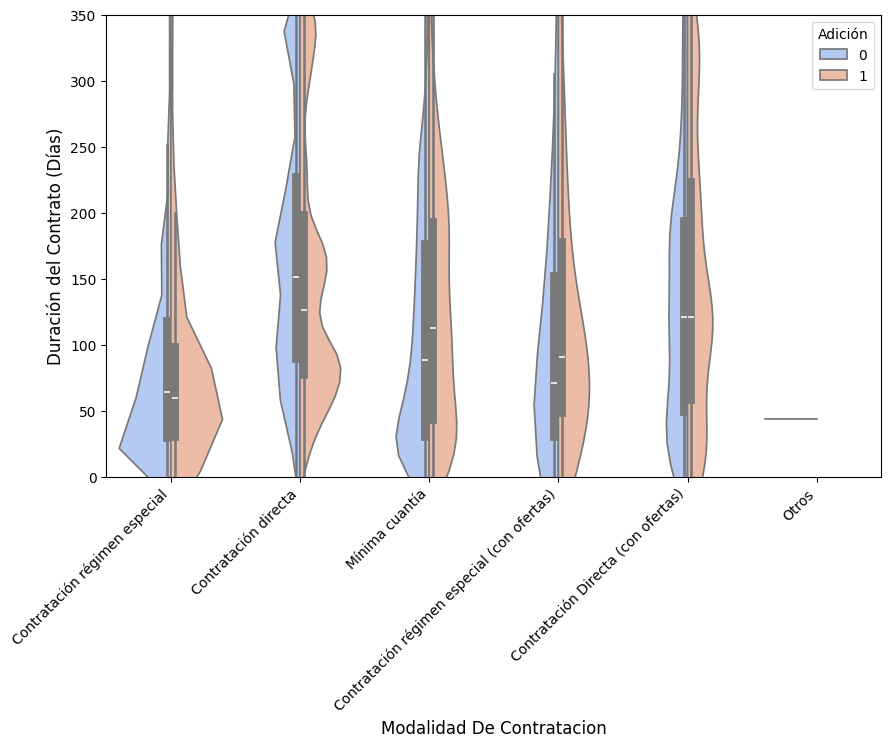

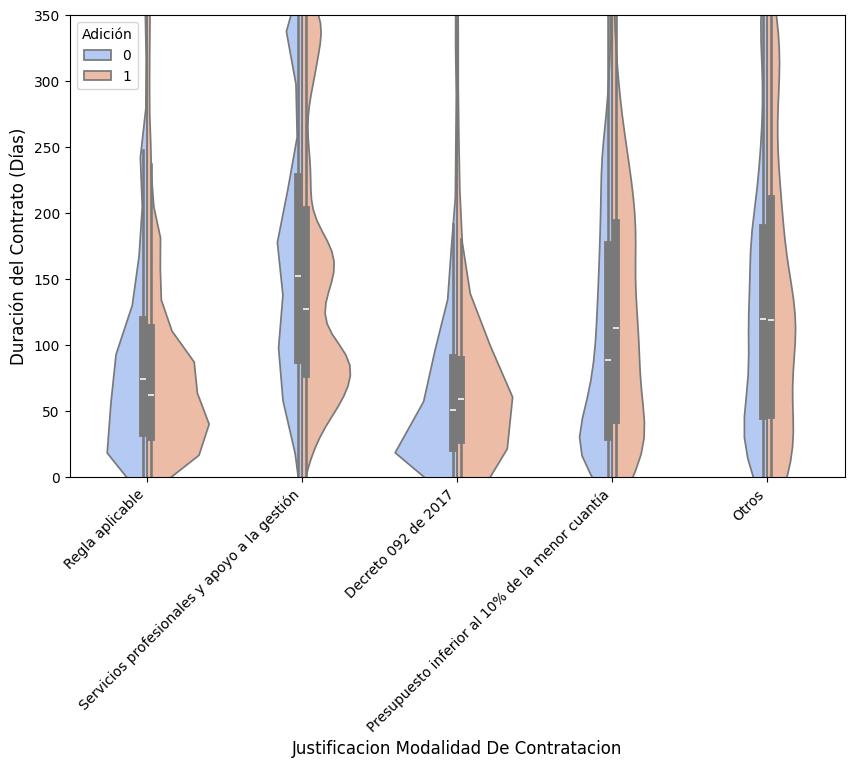

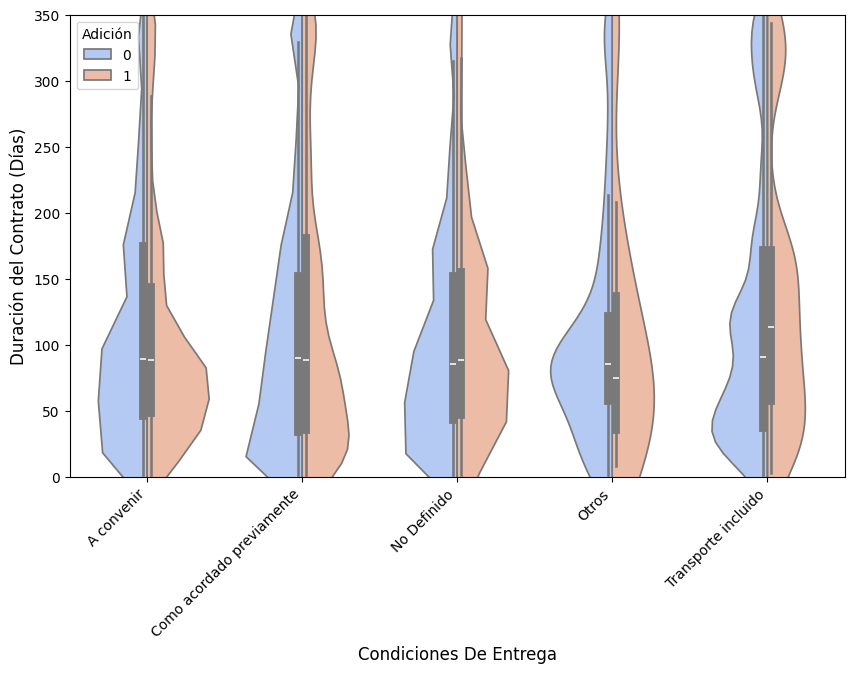

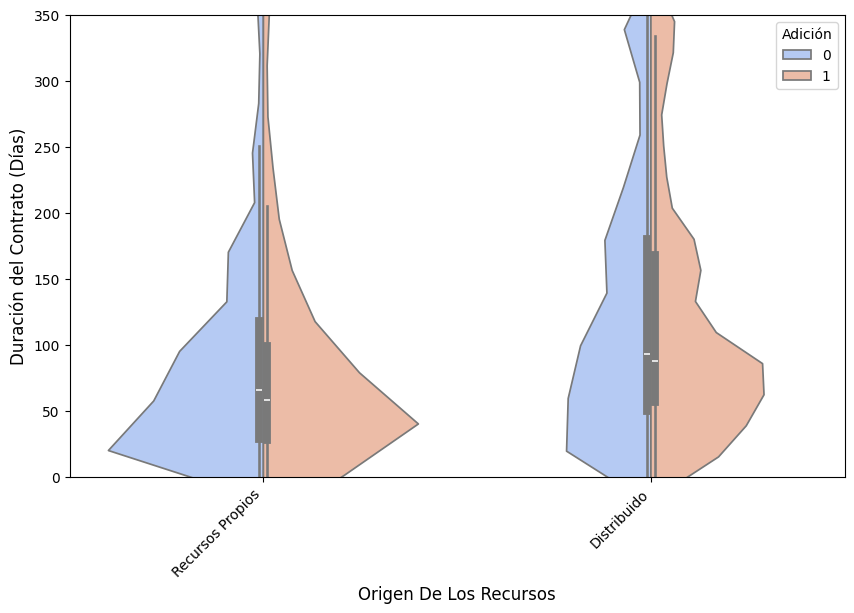

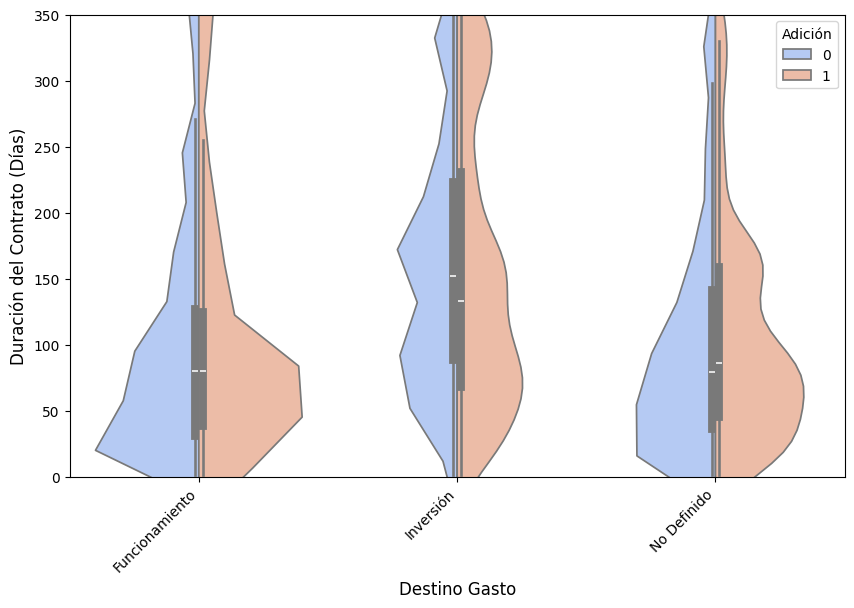

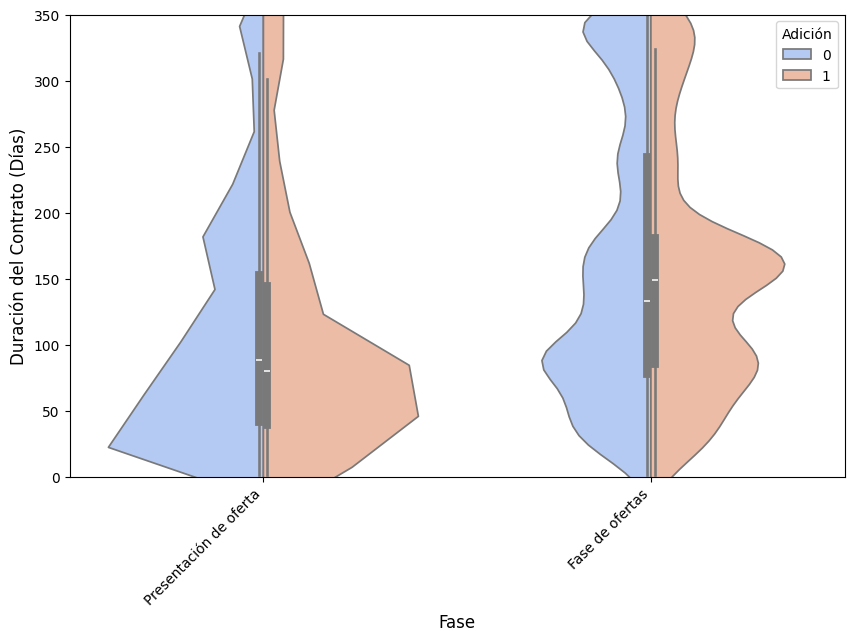

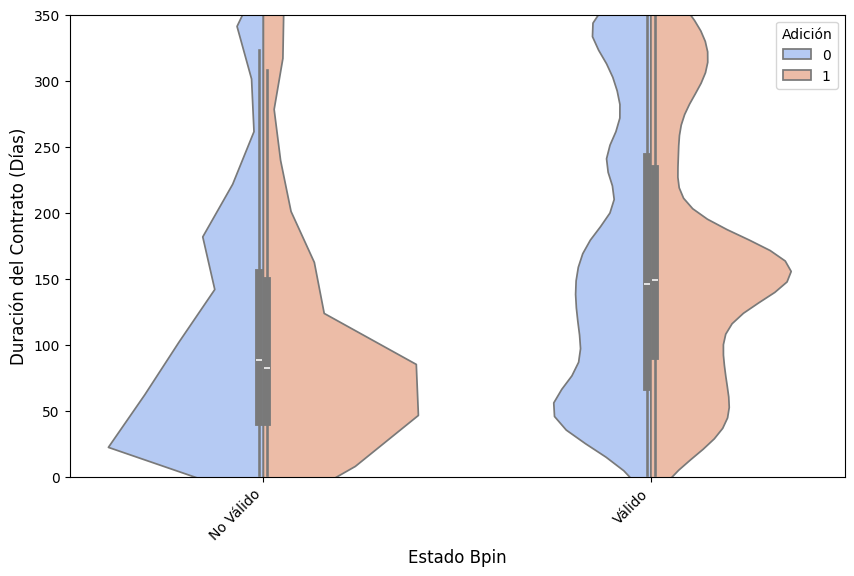

In [97]:
# Filtrar datos sin modificar el DataFrame
variables_categoricas = [
    "estado contrato", "orden", "rama", "entidad centralizada", "tipo de contrato", 
    "modalidad de contratacion", "justificacion modalidad de contratacion", 
    "condiciones de entrega", "origen de los recursos", "destino gasto", "fase","estado bpin"
]

df_filtered = df.dropna(subset=variables_categoricas + ["tiempo duracion (dias)", "Adicion"])

# Crear gráficos de violín para cada variable categórica
for var in variables_categoricas:
    plt.figure(figsize=(10, 6))
    ax = sns.violinplot(x=var, y="tiempo duracion (dias)", hue="Adicion", data=df_filtered, split=True, palette="coolwarm")
    
    # Ajustar la escala eliminando valores atípicos extremos
    ax.set_ylim(0, np.percentile(df_filtered["tiempo duracion (dias)"], 98))

    # Ajustar etiquetas
    plt.xticks(rotation=45, ha="right")
    plt.xlabel(var.replace("_", " ").title(), fontsize=12)
    plt.ylabel("Duración del Contrato (Días)", fontsize=12)

    plt.legend(title="Adición")
    plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_7148\3117393176.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha="right")
C:\Users\user\AppData\Local\Temp\ipykernel_7148\3117393176.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha="right")
C:\Users\user\AppData\Local\Temp\ipykernel_7148\3117393176.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha="right")
C:\Users\user\AppData\Local\Temp\ipykernel_7148\3117393176.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixe

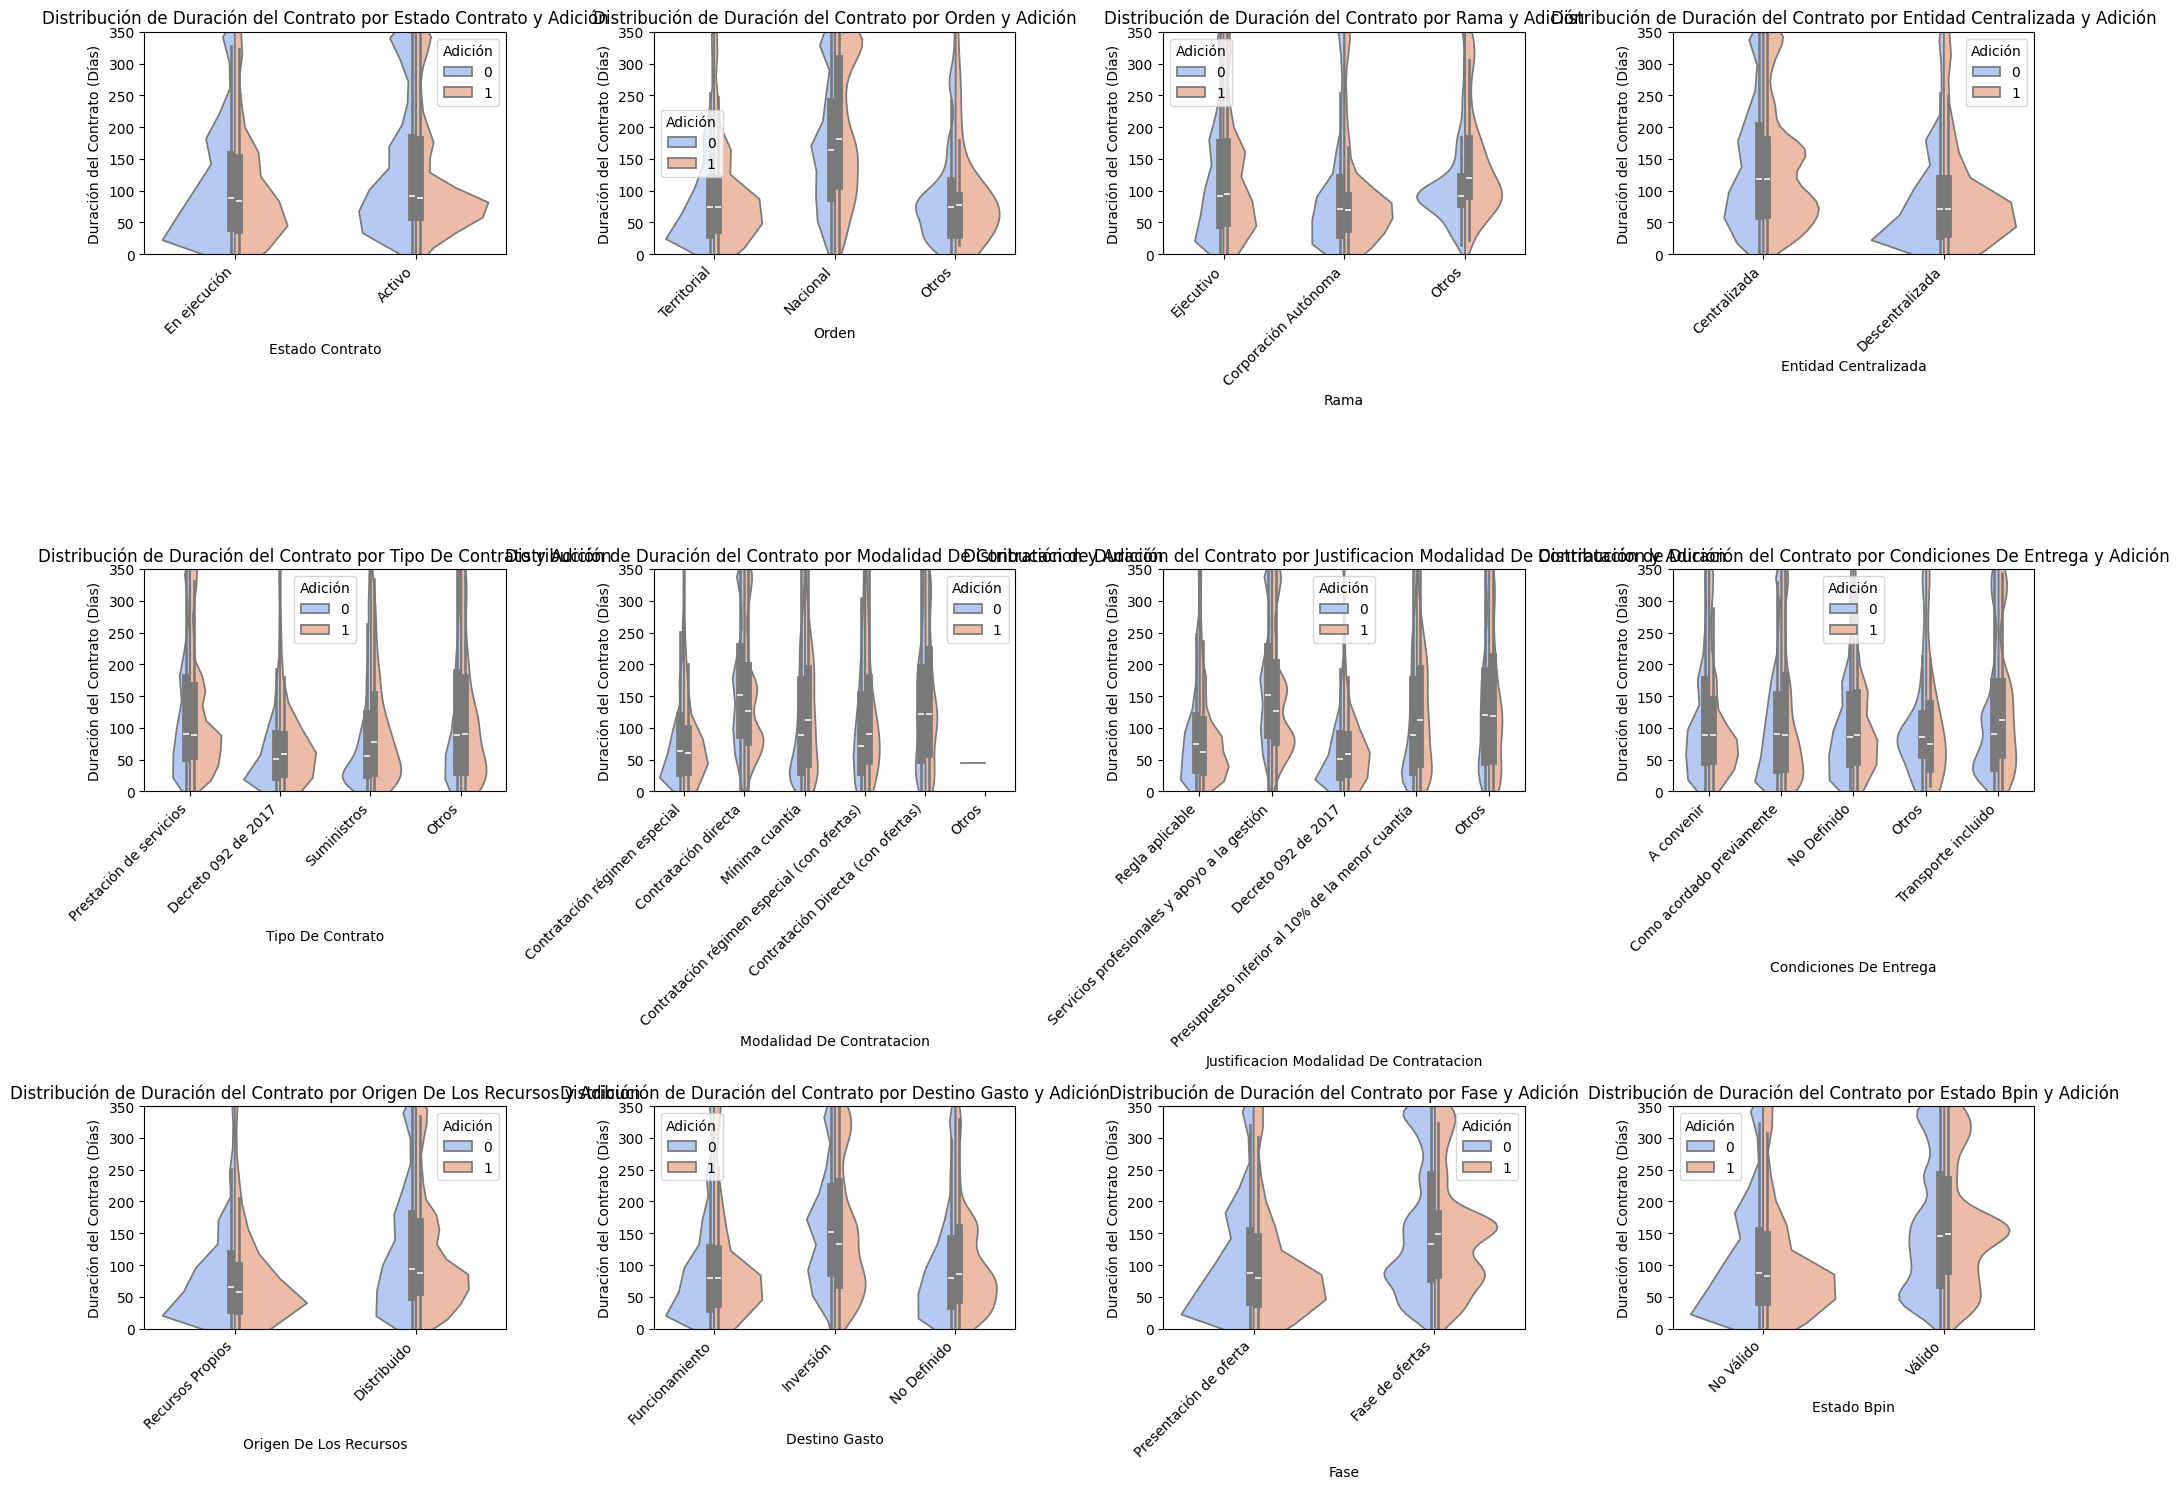

In [138]:
# Filtrar datos sin modificar el DataFrame
variables_categoricas = [
    "estado contrato", "orden", "rama", "entidad centralizada", "tipo de contrato", 
    "modalidad de contratacion", "justificacion modalidad de contratacion", 
    "condiciones de entrega", "origen de los recursos", "destino gasto", "fase", "estado bpin"
]

df_filtered = df.dropna(subset=variables_categoricas + ["tiempo duracion (dias)", "Adicion"])

# Crear una figura con un layout de 4 columnas por fila
num_vars = len(variables_categoricas)
num_cols = 4
num_rows = (num_vars + num_cols - 1) // num_cols  # Calcular el número de filas necesarias

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
axes = axes.flatten()  # Aplanar la matriz de ejes para un acceso más fácil

# Crear gráficos de violín para cada variable categórica
for i, var in enumerate(variables_categoricas):
    sns.violinplot(x=var, y="tiempo duracion (dias)", hue="Adicion", data=df_filtered, split=True, palette="coolwarm", ax=axes[i])
    
    # Ajustar la escala eliminando valores atípicos extremos
    axes[i].set_ylim(0, np.percentile(df_filtered["tiempo duracion (dias)"], 98))

    # Ajustar etiquetas
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha="right")
    axes[i].set_xlabel(var.replace("_", " ").title())
    axes[i].set_ylabel("Duración del Contrato (Días)")
    axes[i].set_title(f"Distribución de Duración del Contrato por {var.replace('_', ' ').title()} y Adición")
    axes[i].legend(title="Adición")

# Eliminar ejes vacíos si hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar el layout para que no se solapen los gráficos
plt.tight_layout()
plt.show()